In [ ]:
import sys, os

import matplotlib.pyplot as plt
import numpy as np
import tqdm
import seaborn as sns

from pathlib import Path
sys.path.append(str(Path.cwd().parents[2]))

from im_net import datamanager, plotting

%load_ext autoreload
%autoreload 2

In [2]:
plot_path = "../figures/appendix/pid_comparison"

plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})
plt.rcParams['svg.fonttype'] = 'none'

## Data Loading

PID atoms computed with five different measures (SX, WB, PM, BROJA, MMI)
for an infomorphic network trained with the redundancy goal.

**Training command:**
```bash
python src/training.py -m storage=cluster params.pref_gpu=False params.seed='range(10)' params.alpha='range(0.05,2.05,0.05)' storage.final.pid=True storage.alt_pids=[SX,WB,PM,BROJA,MMI]
```

In [ ]:
# TODO: set path to PID measure comparison experiment folder
path = ''

dm = datamanager.DataManager(path, mode='analysis', add_run_properties=True, verbose=0)
dm.sel = dm.all[dm.all['finished'] == True]
dm.sel = dm.sel.sort_values(by=['params.alpha', 'params.seed'])

pid_sx    = dm.load_selected('SX')
pid_wb    = dm.load_selected('WB')
pid_pm    = dm.load_selected('PM')
pid_broja = dm.load_selected('BROJA')
pid_mmi   = dm.load_selected('MMI')

alpha  = dm.sel['params.alpha'].to_numpy()
n_runs, n_alphas = dm.sel.shape[0] // len(np.unique(alpha)), len(np.unique(alpha))

sx_pid    = np.zeros((n_alphas, n_runs, 4))
wb_pid    = np.zeros((n_alphas, n_runs, 4))
pm_pid    = np.zeros((n_alphas, n_runs, 4))
broja_pid = np.zeros((n_alphas, n_runs, 4))
mmi_pid   = np.zeros((n_alphas, n_runs, 4))

for i in tqdm.tqdm(range(n_alphas)):
    for j in range(n_runs):
        sx_pid[i, j]    = np.mean(np.array(pid_sx[j + i * n_runs]['layer1'][0]),    axis=1)
        wb_pid[i, j]    = np.mean(np.array(pid_wb[j + i * n_runs]['layer1'][0]),    axis=1)
        pm_pid[i, j]    = np.mean(np.array(pid_pm[j + i * n_runs]['layer1'][0]),    axis=1)
        broja_pid[i, j] = np.mean(np.array(pid_broja[j + i * n_runs]['layer1'][0]), axis=1)
        mmi_pid[i, j]   = np.mean(np.array(pid_mmi[j + i * n_runs]['layer1'][0]),   axis=1)

print(f"Loaded {n_alphas} alpha values, {n_runs} seeds per measure.")

100%|██████████| 40/40 [00:00<00:00, 817.91it/s]

Loaded 40 alpha values, 20 seeds per measure.


## Figure: PID Measure Comparison

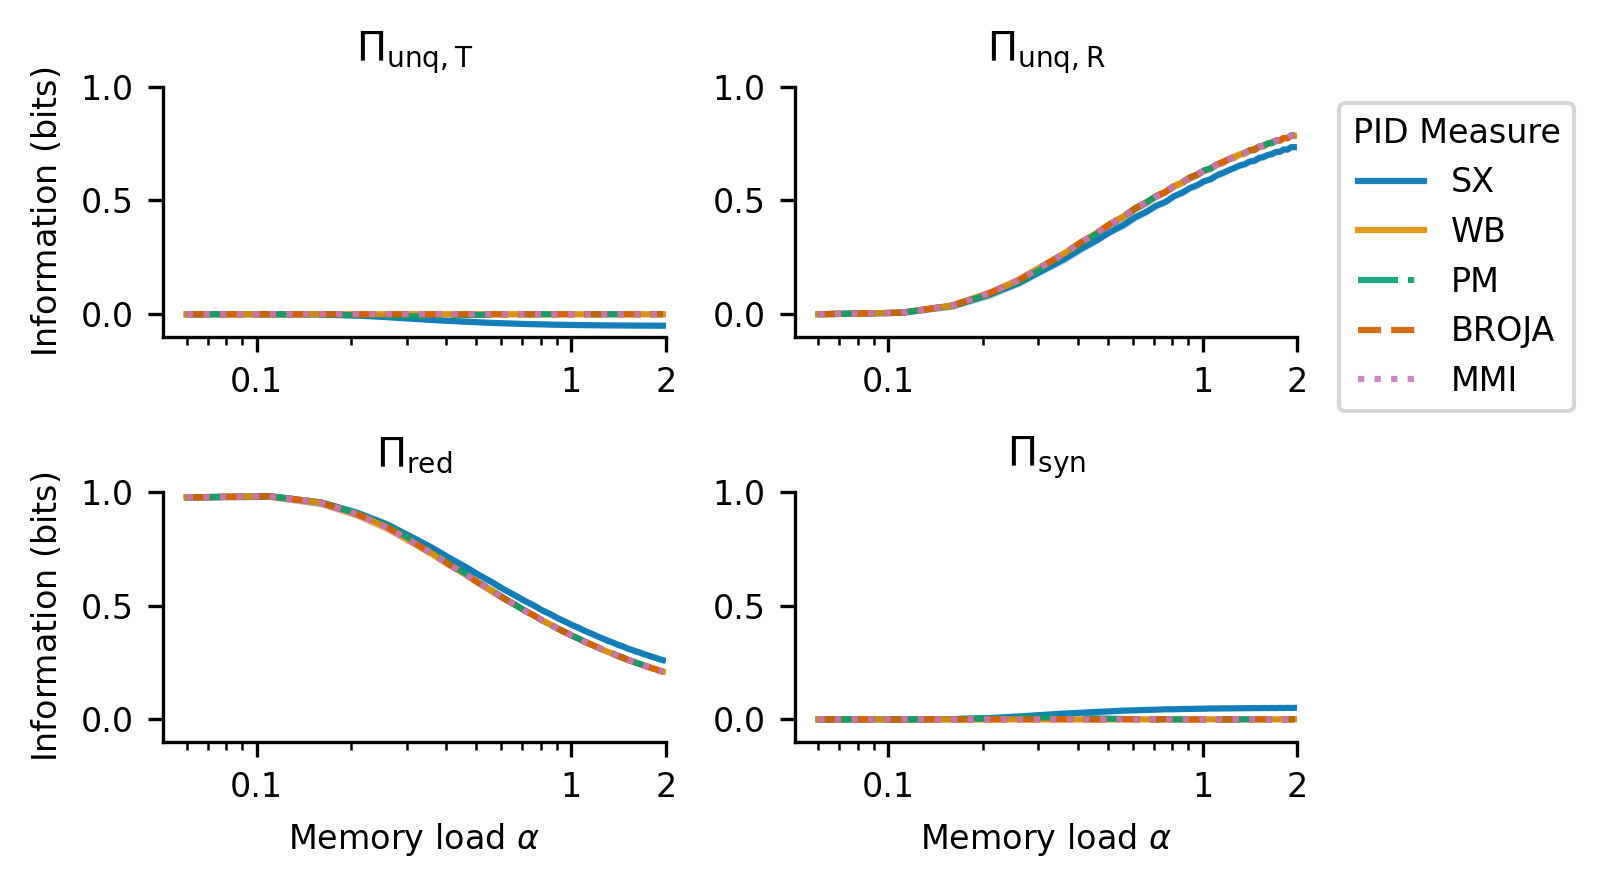

In [4]:
color     = sns.color_palette("colorblind", 5)
titles    = [r'$\Pi_{\mathrm{unq,T}}$', r'$\Pi_{\mathrm{unq,R}}$',
             r'$\Pi_{\mathrm{red}}$',   r'$\Pi_{\mathrm{syn}}$']
linestyle = ['-', '-', '-.', '--', ':']
pids      = [sx_pid, wb_pid, pm_pid, broja_pid, mmi_pid]
pid_names = ['SX', 'WB', 'PM', 'BROJA', 'MMI']
a         = np.unique(alpha)
s         = 1  # skip α=0

fig, ax = plt.subplots(2, 2, figsize=(4.5, 3), sharex=True, sharey=True)
ax = ax.flatten()

for j in range(4):
    ax[j].set_title(titles[j])
    for idx, (pid, label) in enumerate(zip(pids, pid_names)):
        ax[j].plot(a[s:], np.median(pid[s:, :, j], axis=1),
                   label=label, alpha=0.9, linestyle=linestyle[idx], color=color[idx])
        ax[j].fill_between(a[s:],
                           np.percentile(pid[s:, :, j], 0,   axis=1),
                           np.percentile(pid[s:, :, j], 100, axis=1),
                           alpha=0.2, color=color[idx])
    ax[j].set_xscale('log')
    ax[j].set_xlim((None, 2))
    plotting.adjust_spines(ax[j], ['left', 'bottom'], offset_spines=[0, 0])

ax[0].set_ylim(-0.1, 1)
ax[0].set_ylabel(r'$\mathrm{Information\ (bits)}$')
ax[2].set_ylabel(r'$\mathrm{Information\ (bits)}$')
ax[3].set_xticks([0.1, 1, 2])
ax[3].set_xticklabels(['0.1', '1', '2'])
ax[2].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$')
ax[3].set_xlabel(r'$\mathrm{Memory\ load}\ \alpha$')

fig.tight_layout()
ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='PID Measure')
# fig.savefig(f"{plot_path}/pid_comparison.svg", bbox_inches='tight')
plt.show()